In [18]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

### Import needed dependancies

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV



### Handle data

* Load the dataset at hand

In [20]:
original_data = pd.read_csv("Data_set/creditcard.csv")
original_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
original_data.info()    


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [22]:
# check for missing values 
original_data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [23]:
# check for duplicates
original_data.duplicated().sum()

#drop duplicates
original_data.drop_duplicates(inplace=True)

# check for duplicates again
original_data.duplicated().sum()

np.int64(0)

In [24]:
# count the number of fraud and non-fraud cases
original_data["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

* This is a class imbalance directly 

  * First we sample the data well 

In [25]:
# Get the count of the minority class (Class == 1) from the original dataset

class_1_count = original_data[original_data["Class"] == 1].shape[0]
print(f"Number of fraud cases (Class 1): {class_1_count}")

Number of fraud cases (Class 1): 473


In [26]:
# Sample an equal number of instances from Class == 0 and all instances from Class == 1

class_0_sample = original_data[original_data["Class"] == 0].sample(n=class_1_count, random_state=42)
class_1_data = original_data[original_data["Class"] == 1]

# Combine the sampled Class == 0 data with all Class == 1 data to create a balanced dataset
balanced_data = pd.concat([class_0_sample, class_1_data], axis=0)
# Shuffle the balanced dataset
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_data["Class"].value_counts()

Class
0    473
1    473
Name: count, dtype: int64

In [27]:
balanced_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,...,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,89046.217759,-2.288689,1.717067,-3.381647,2.260859,-1.476409,-0.710754,-2.556664,0.468655,-1.251582,...,0.249491,-0.011015,-0.041263,-0.044789,0.021174,0.037166,0.112254,0.046365,111.665021,0.500000
std,48977.566722,5.339158,3.568913,6.006512,3.176319,4.103449,1.658880,5.559057,4.060295,2.300830,...,2.045941,0.989506,1.121136,0.560130,0.670881,0.473487,0.936664,0.460300,271.883796,0.500264
min,241.000000,-30.552380,-12.541876,-31.103685,-3.535523,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.174693,-7.263482,-4.948943,0.000000,0.000000
25%,47715.750000,-2.868965,-0.131280,-4.967099,-0.021661,-1.689196,-1.529322,-2.931036,-0.186555,-2.276051,...,-0.208432,-0.596979,-0.235633,-0.394596,-0.320043,-0.288452,-0.063575,-0.052002,1.682500,0.000000
50%,82903.000000,-0.813860,1.034220,-1.347904,1.364654,-0.392842,-0.641937,-0.591065,0.148182,-0.715968,...,0.132153,-0.051699,-0.029564,0.023343,0.045041,0.005491,0.047777,0.036296,18.960000,0.500000
75%,135879.500000,1.001483,2.789262,0.284606,4.220067,0.513236,0.053654,0.288136,0.863595,0.179981,...,0.650170,0.521007,0.199456,0.376333,0.391117,0.359631,0.459538,0.218938,99.990000,1.000000
max,172717.000000,2.388836,22.057729,3.225532,12.114672,11.095089,8.244267,7.418631,20.007208,7.883641,...,27.202839,8.361985,5.466230,1.166470,2.208209,2.745261,3.343366,3.440544,3789.800000,1.000000


In [29]:
# Save the new balanced samled data 

balanced_data.to_csv("Data_set/balanced_creditcard.csv", index = False)

##### Visualize distribution of each variable while saving it 

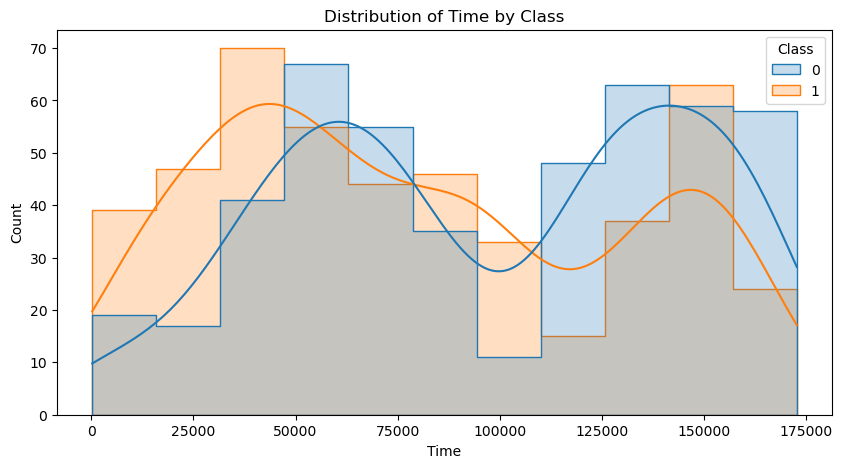

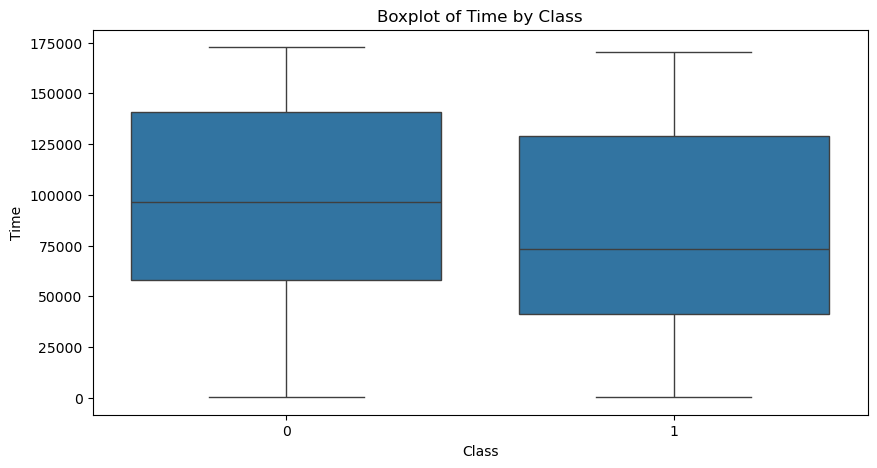

<Figure size 640x480 with 0 Axes>

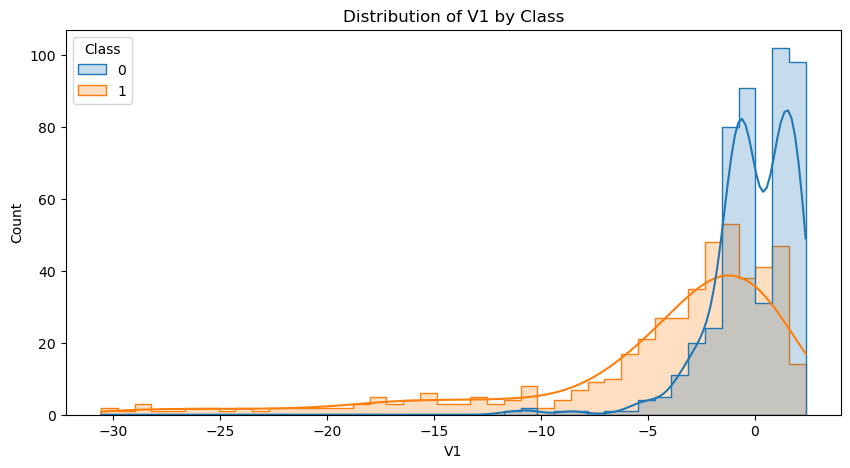

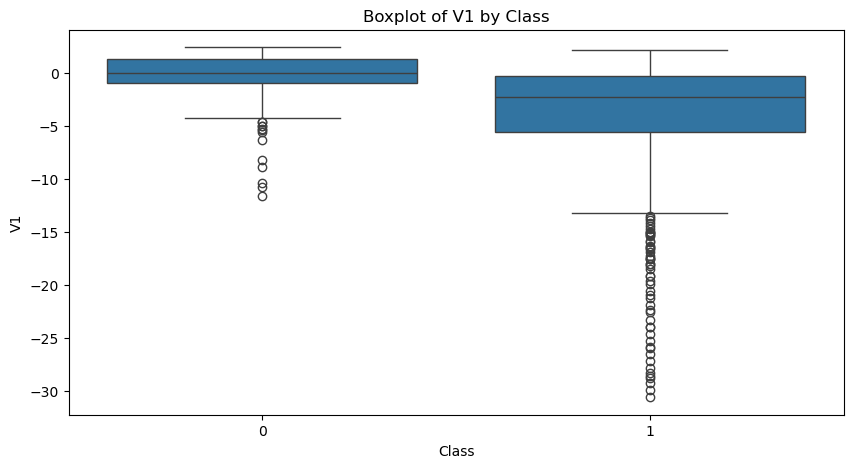

<Figure size 640x480 with 0 Axes>

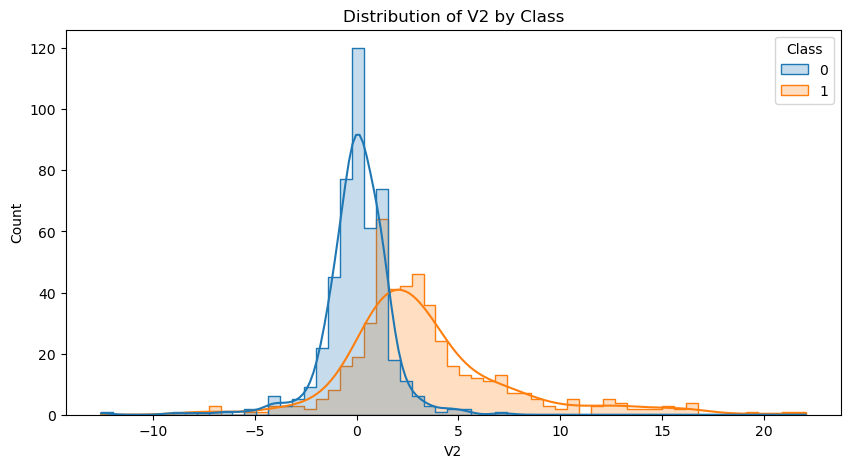

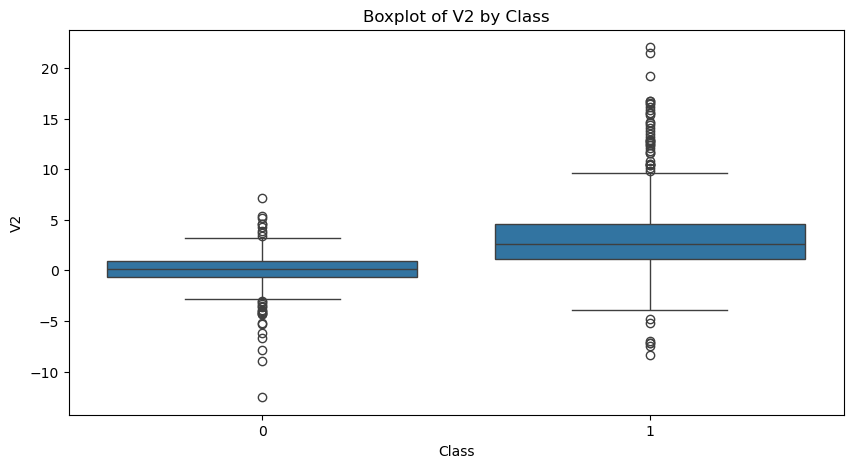

<Figure size 640x480 with 0 Axes>

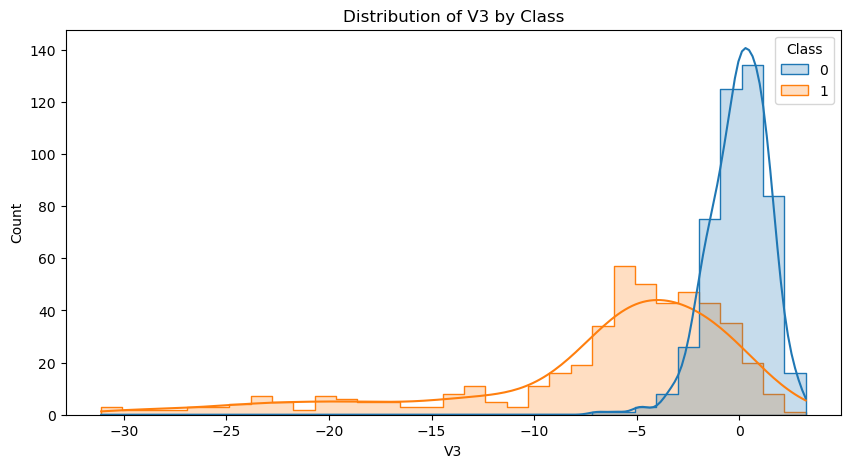

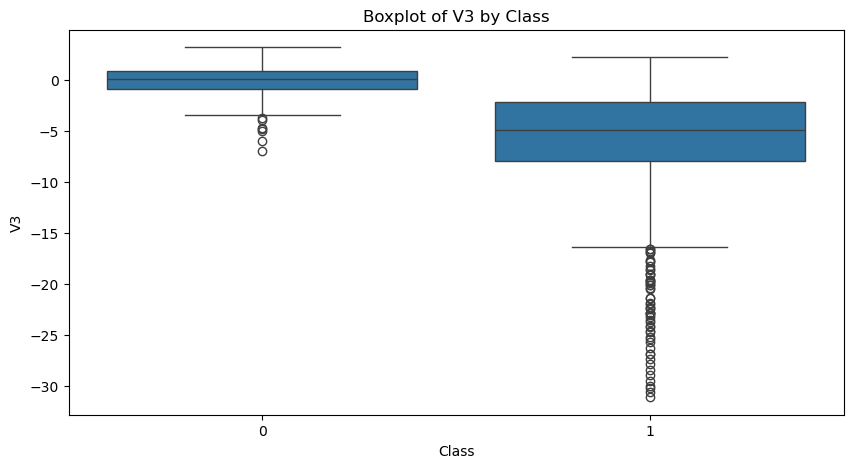

<Figure size 640x480 with 0 Axes>

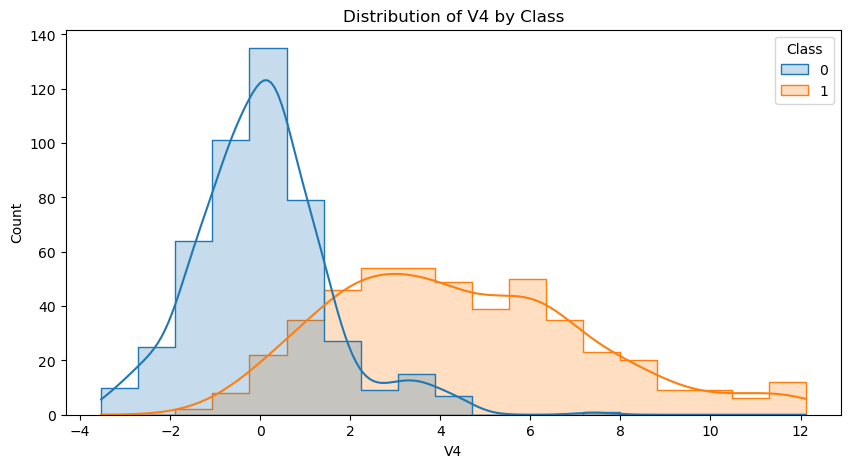

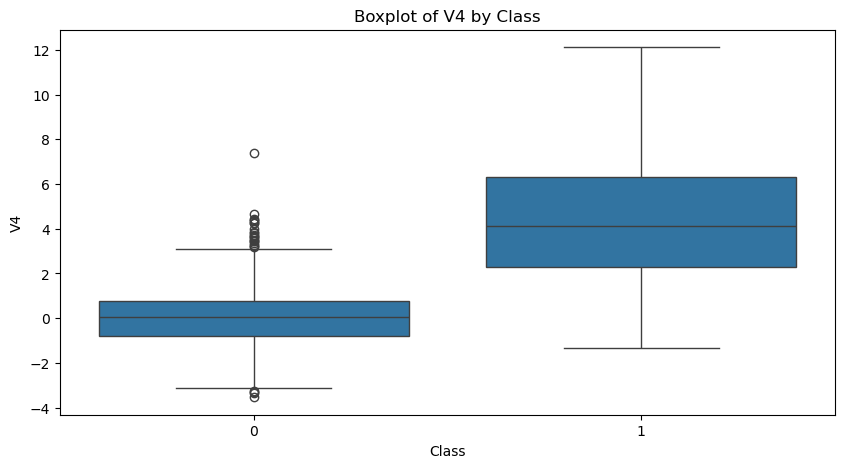

<Figure size 640x480 with 0 Axes>

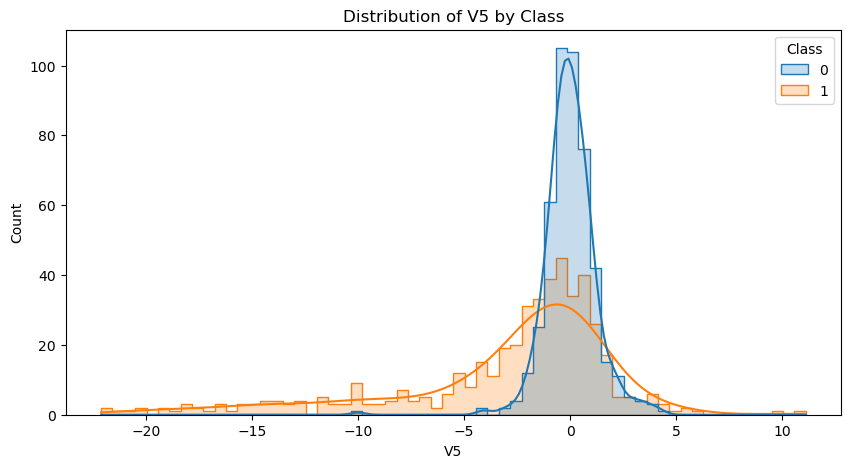

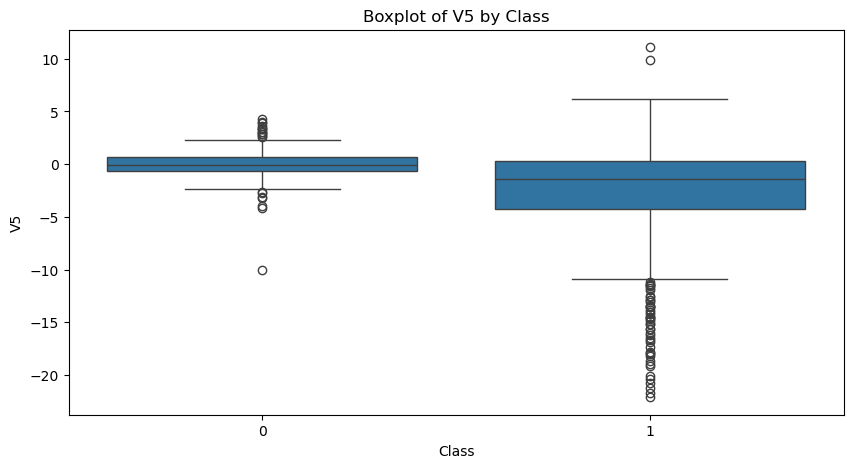

<Figure size 640x480 with 0 Axes>

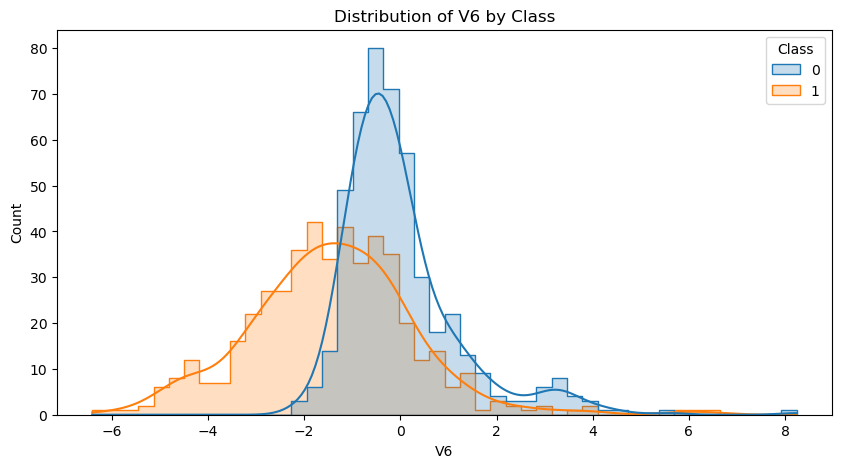

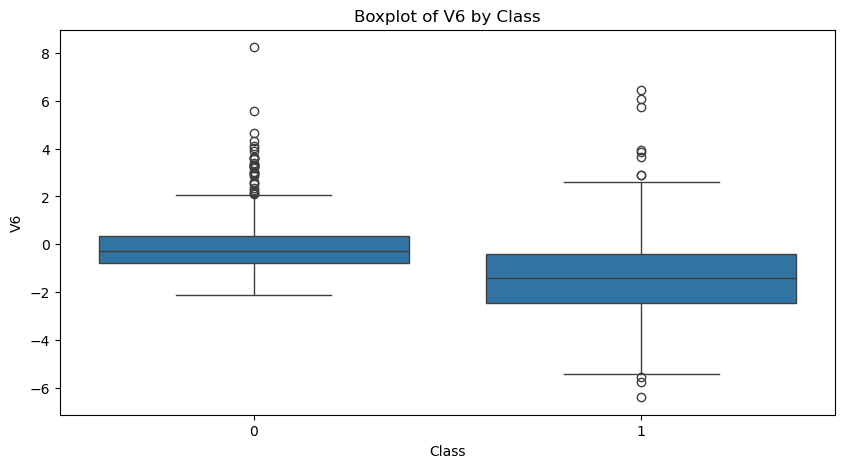

<Figure size 640x480 with 0 Axes>

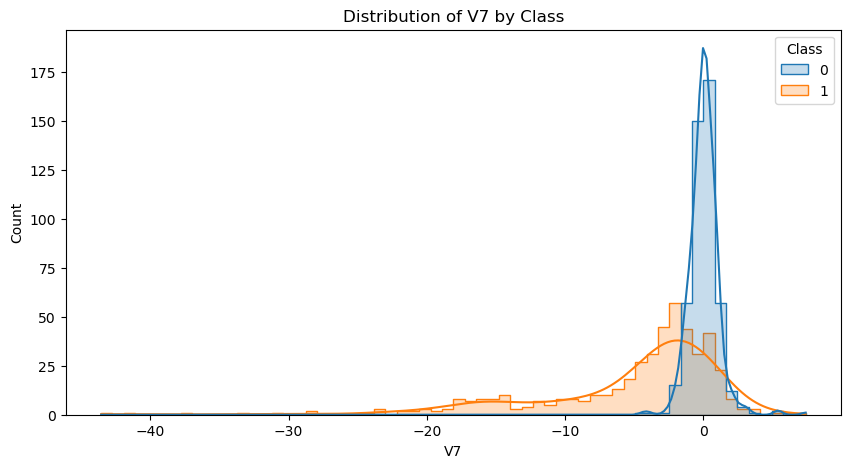

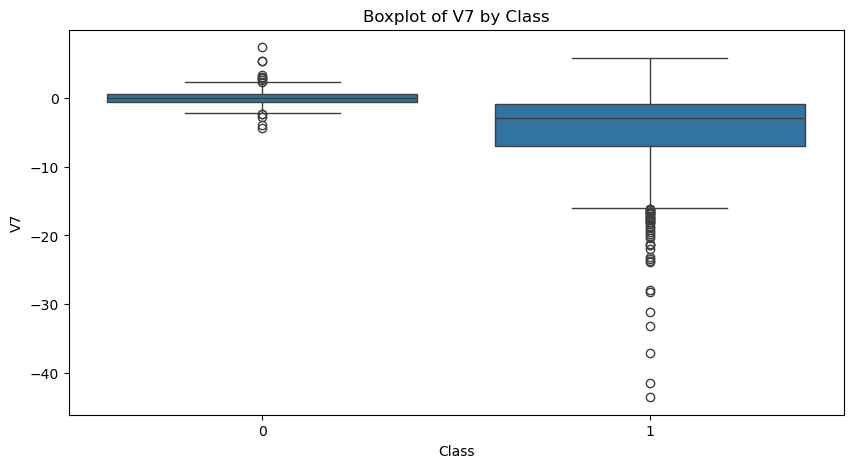

<Figure size 640x480 with 0 Axes>

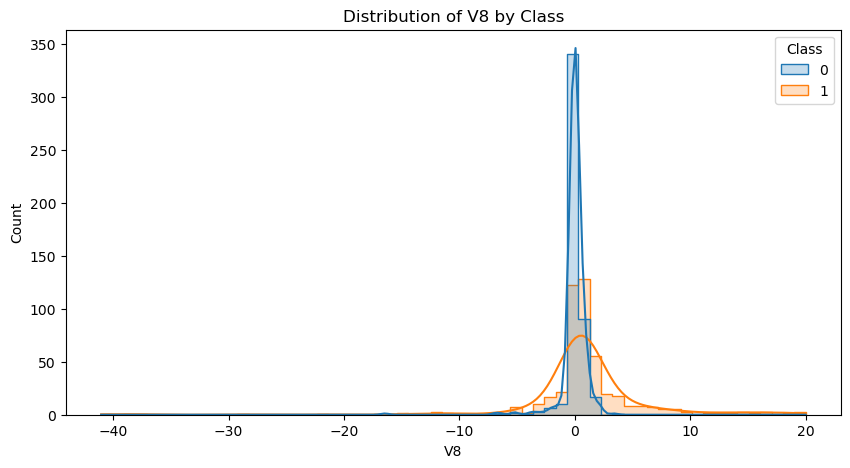

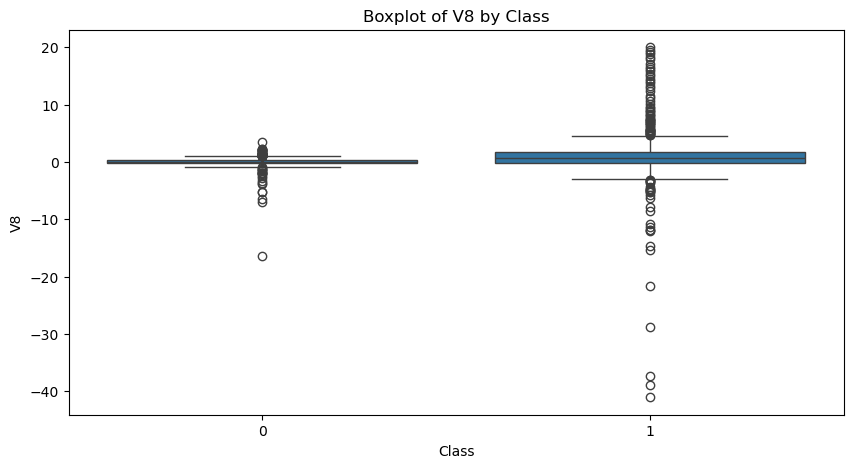

<Figure size 640x480 with 0 Axes>

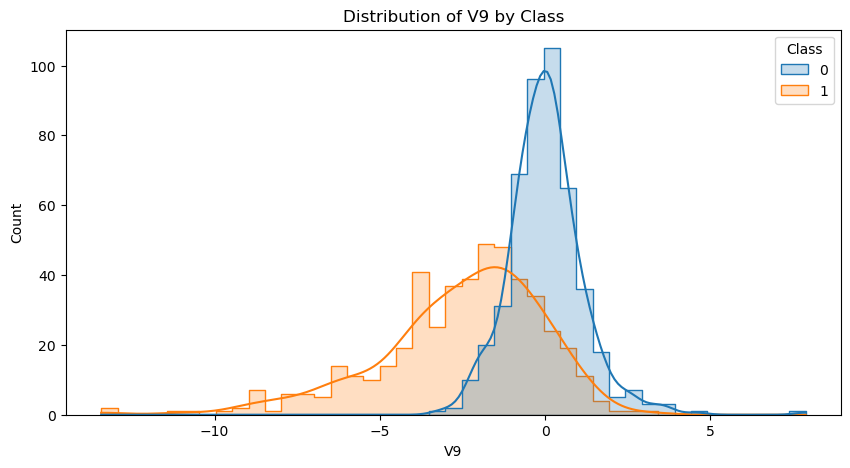

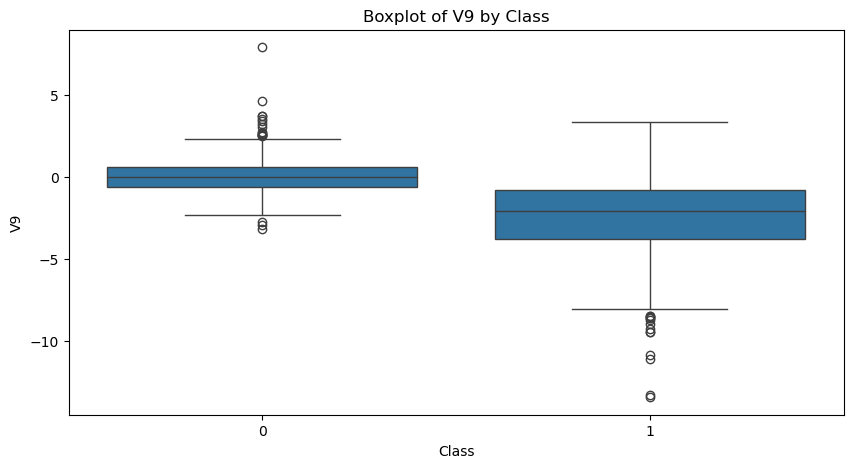

<Figure size 640x480 with 0 Axes>

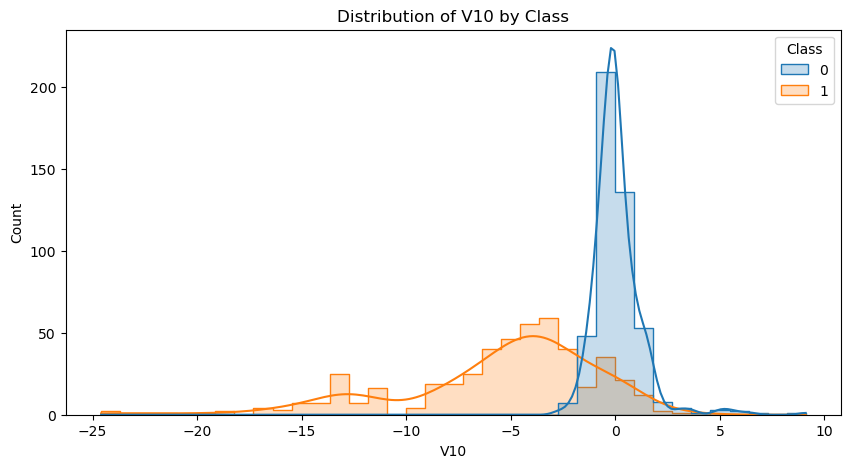

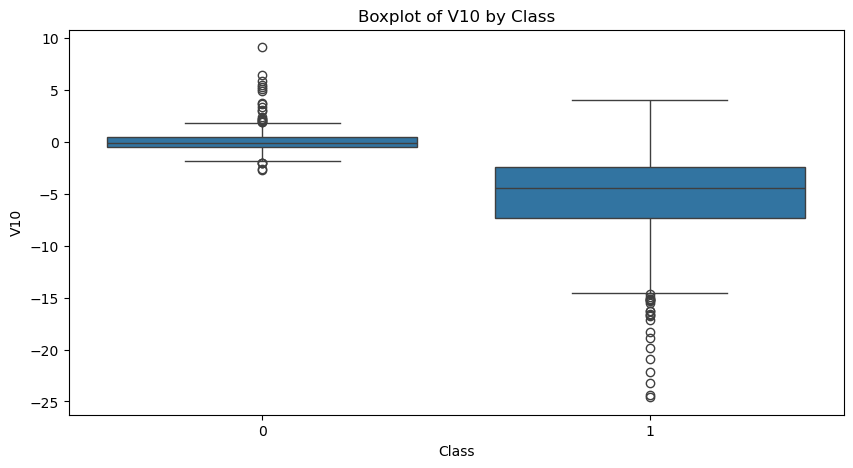

<Figure size 640x480 with 0 Axes>

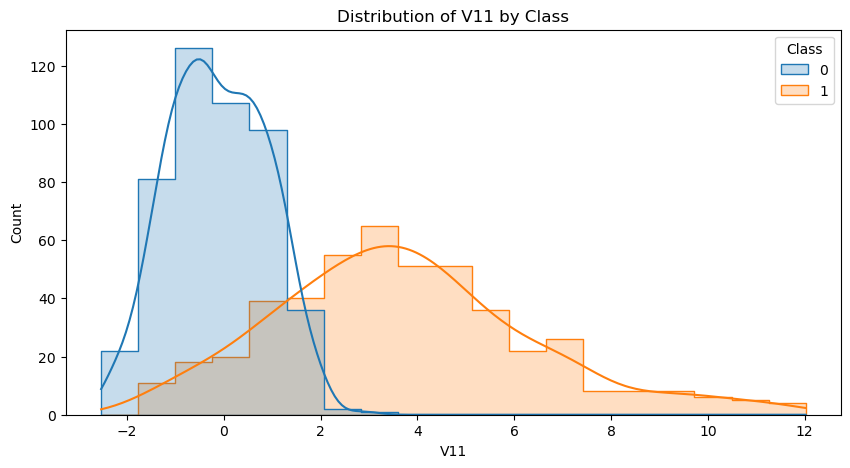

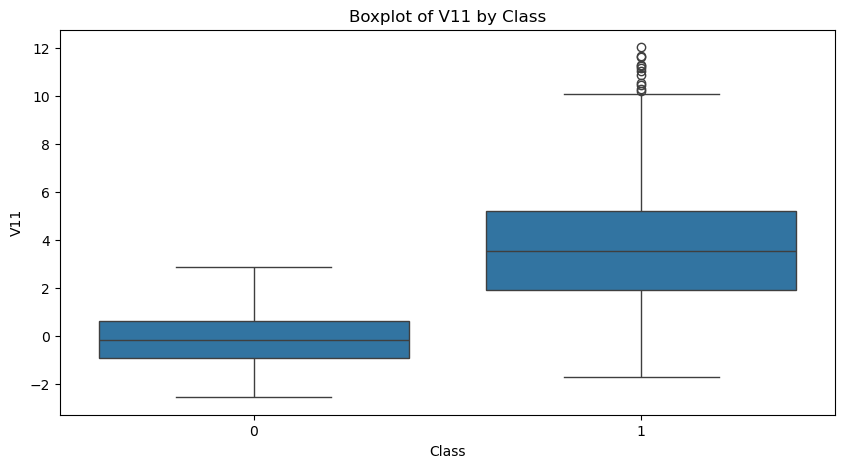

<Figure size 640x480 with 0 Axes>

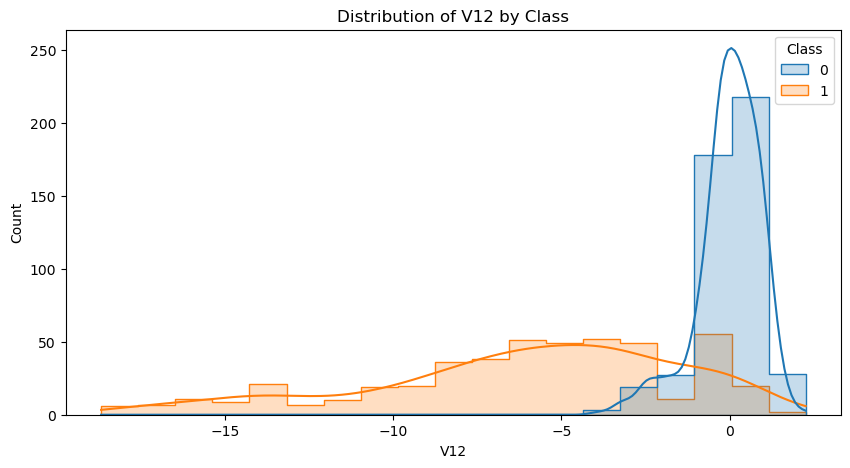

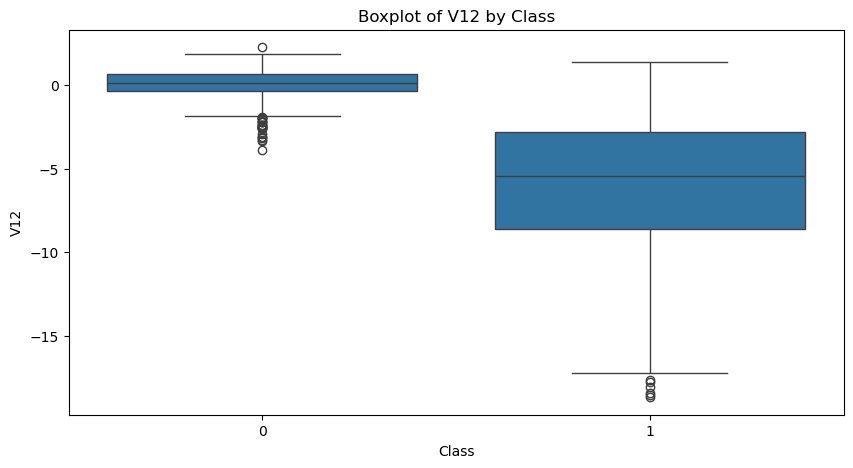

<Figure size 640x480 with 0 Axes>

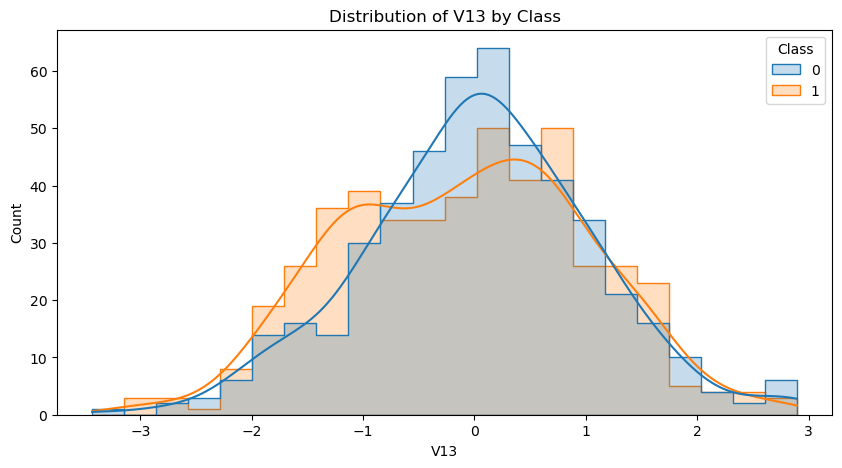

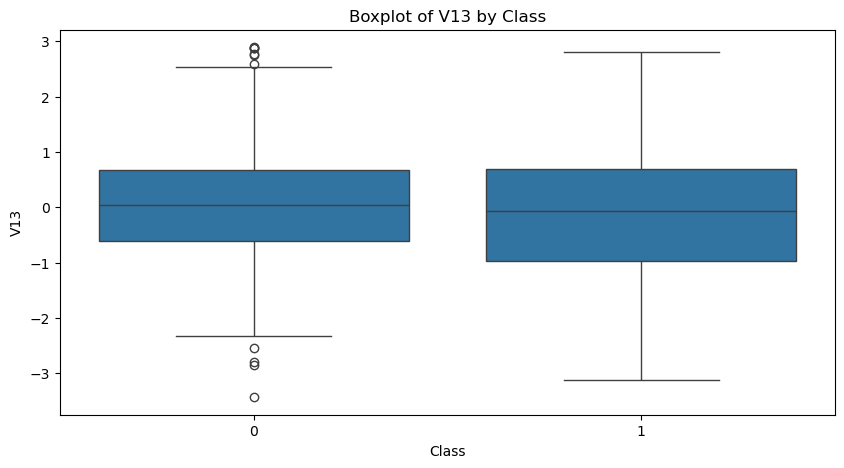

<Figure size 640x480 with 0 Axes>

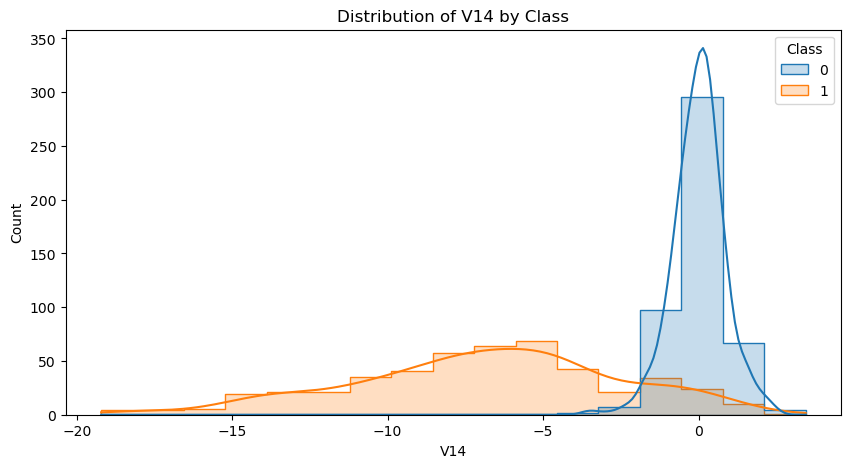

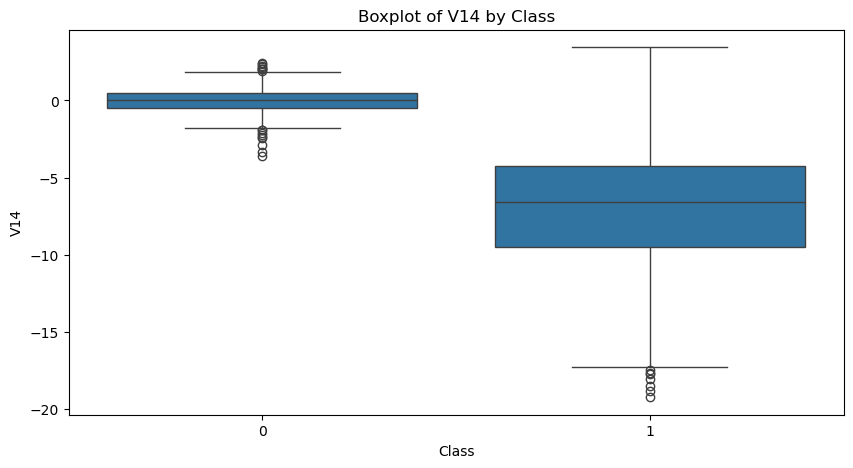

<Figure size 640x480 with 0 Axes>

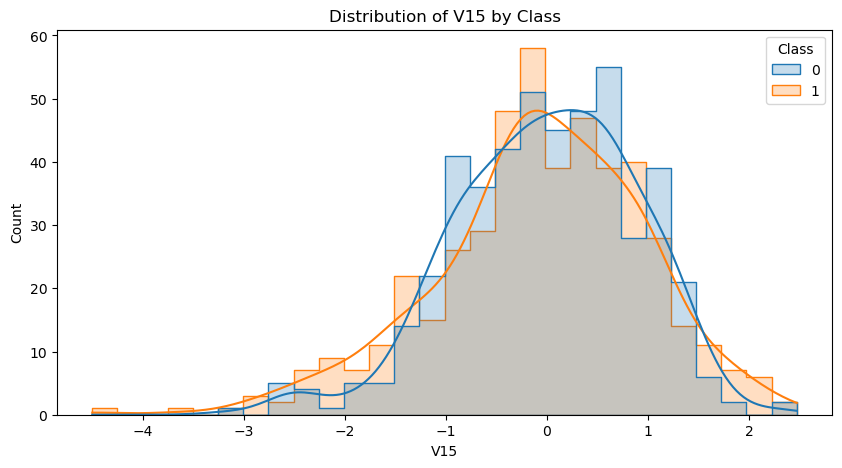

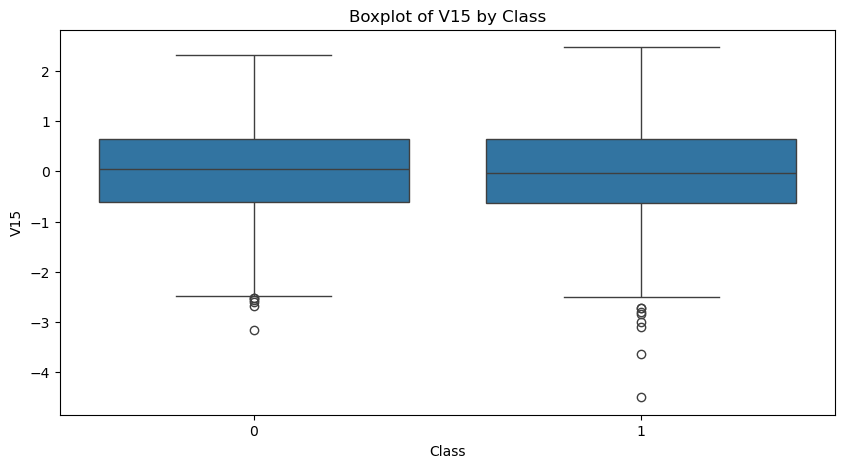

<Figure size 640x480 with 0 Axes>

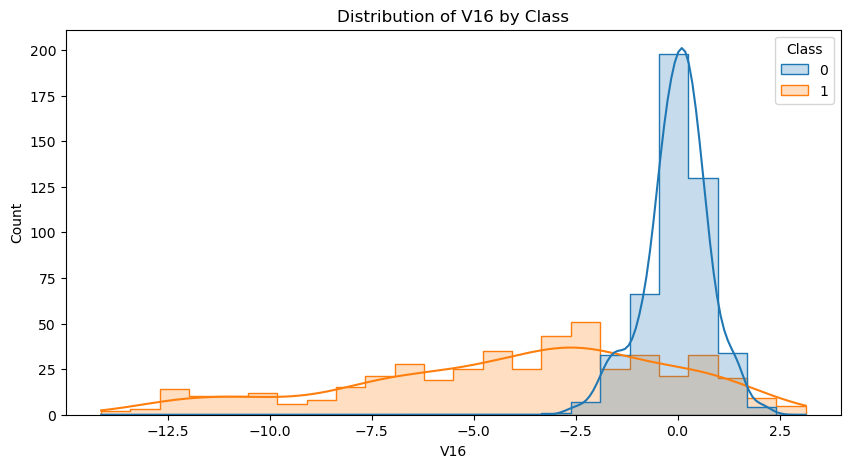

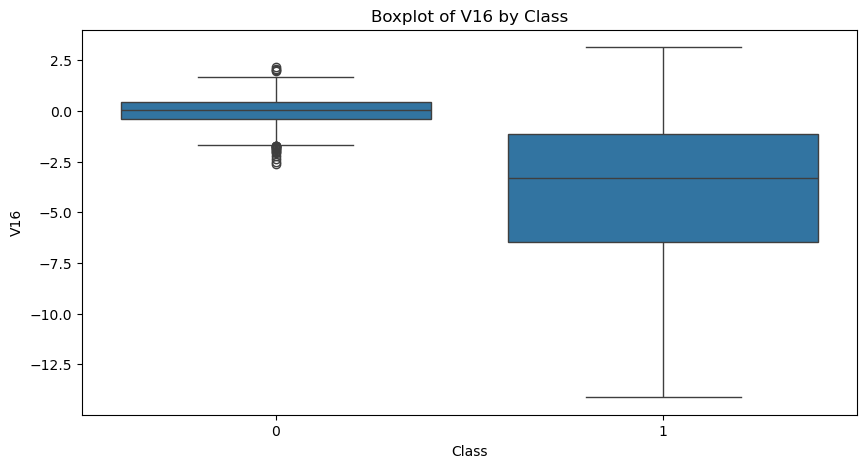

<Figure size 640x480 with 0 Axes>

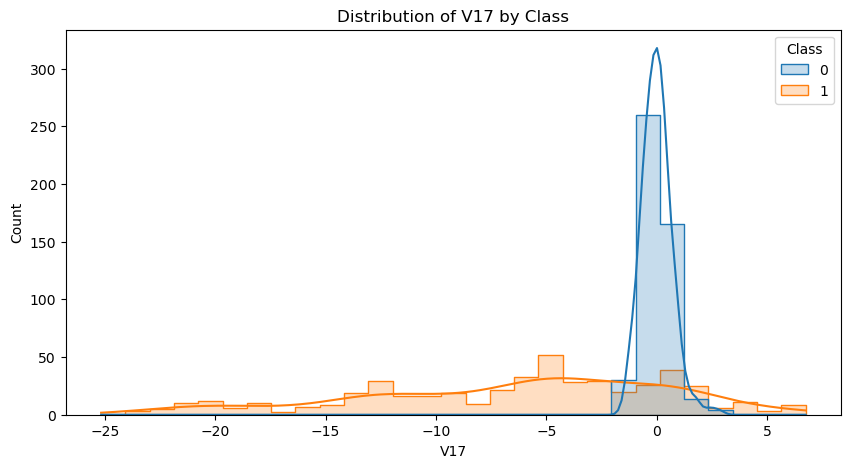

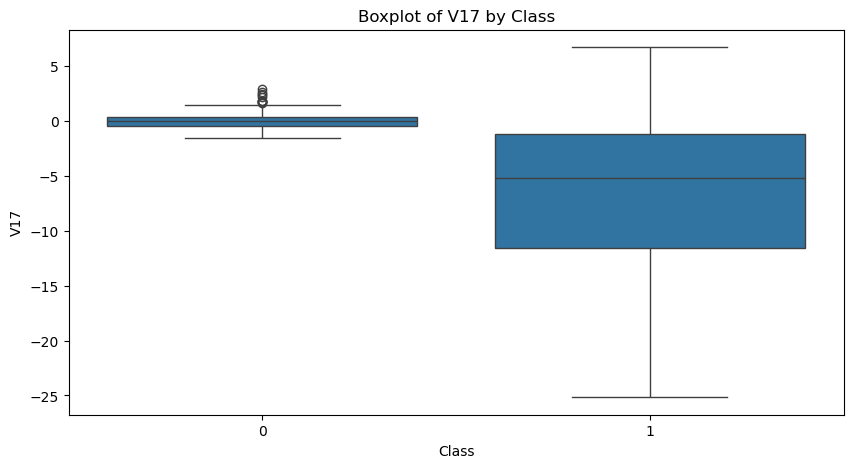

<Figure size 640x480 with 0 Axes>

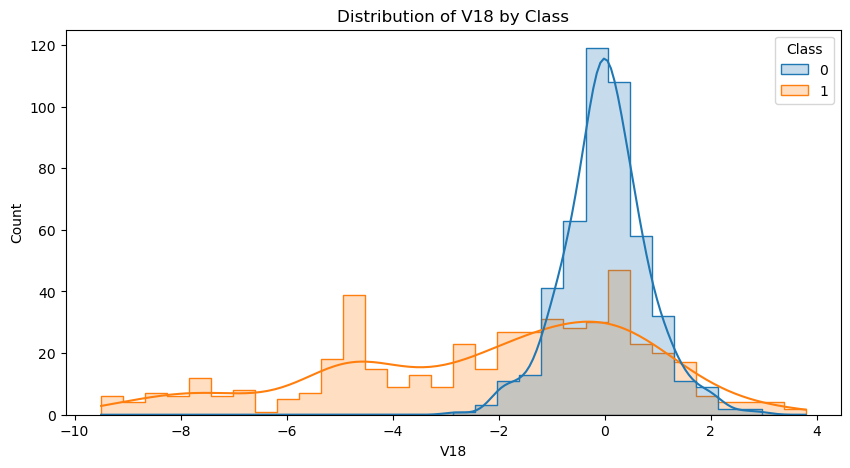

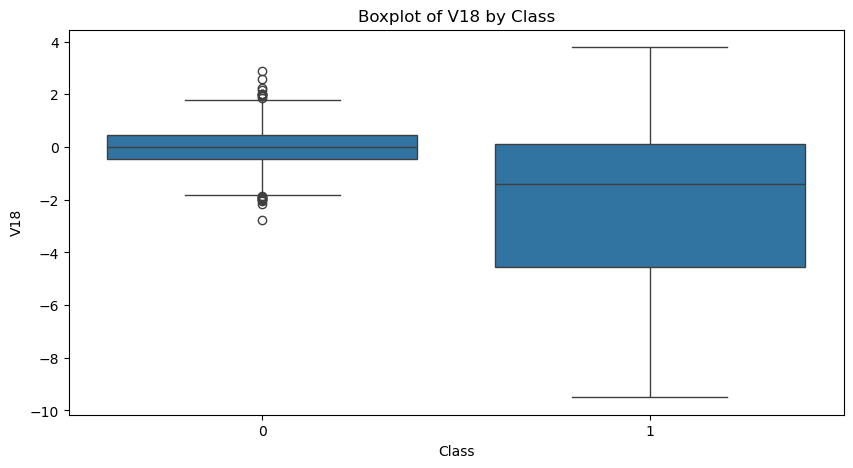

<Figure size 640x480 with 0 Axes>

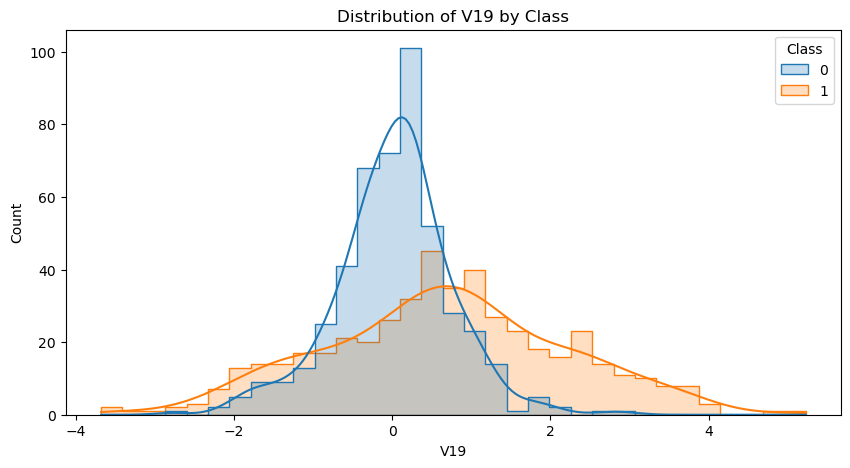

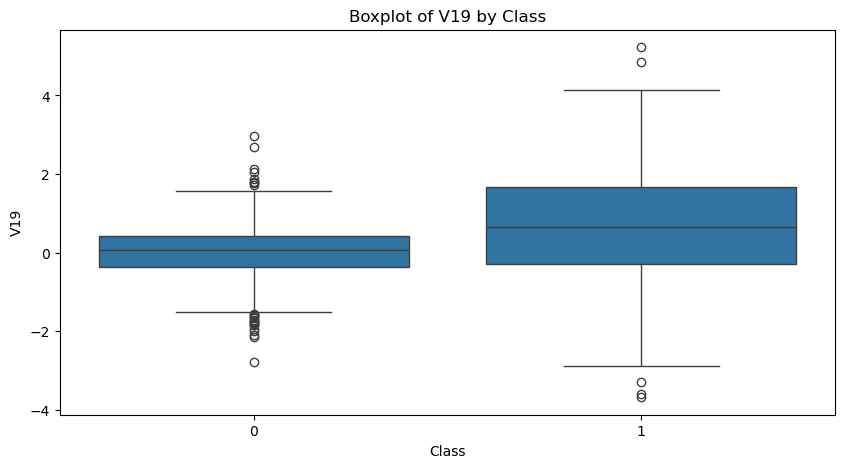

<Figure size 640x480 with 0 Axes>

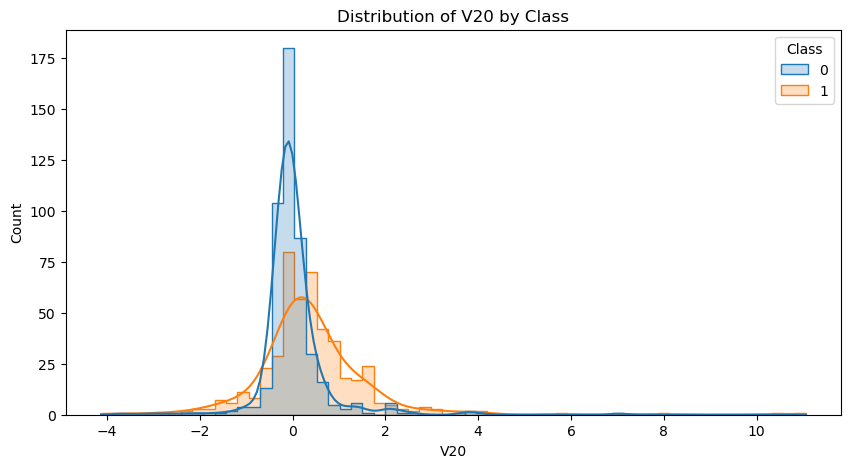

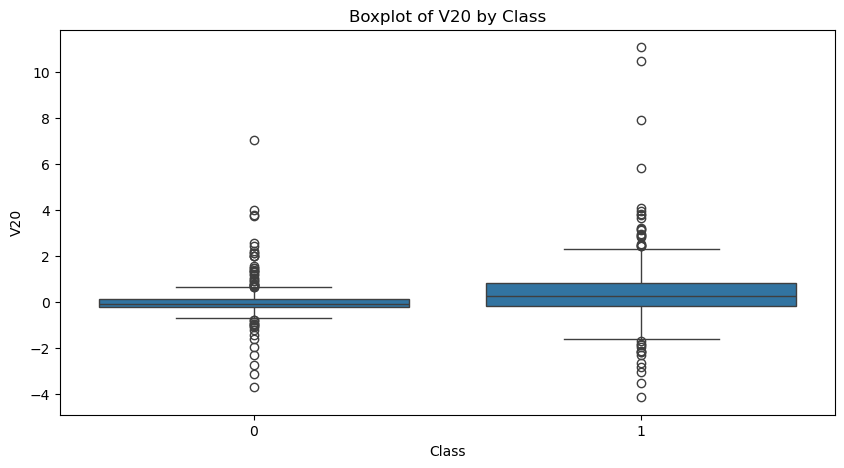

<Figure size 640x480 with 0 Axes>

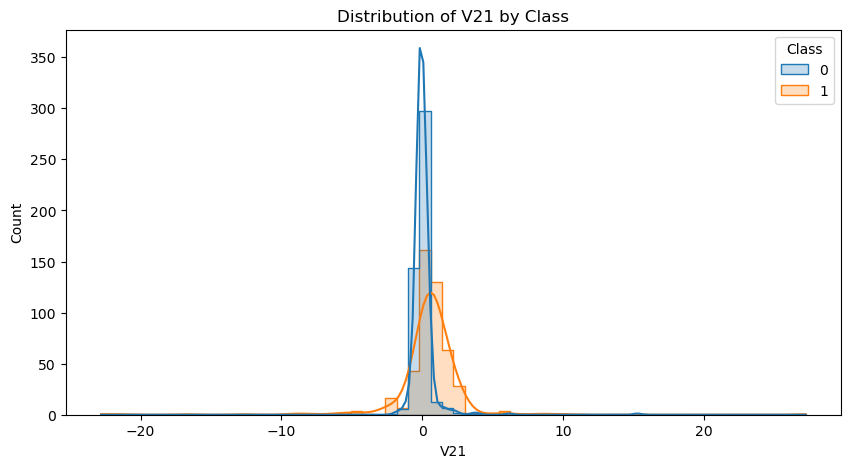

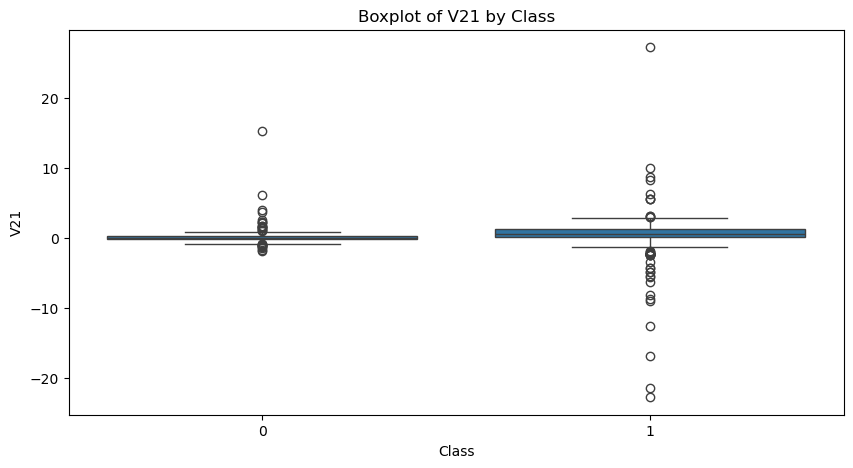

<Figure size 640x480 with 0 Axes>

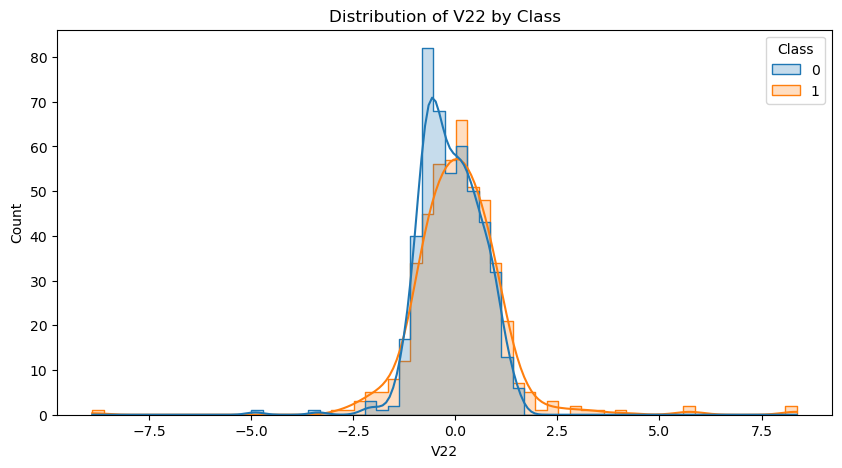

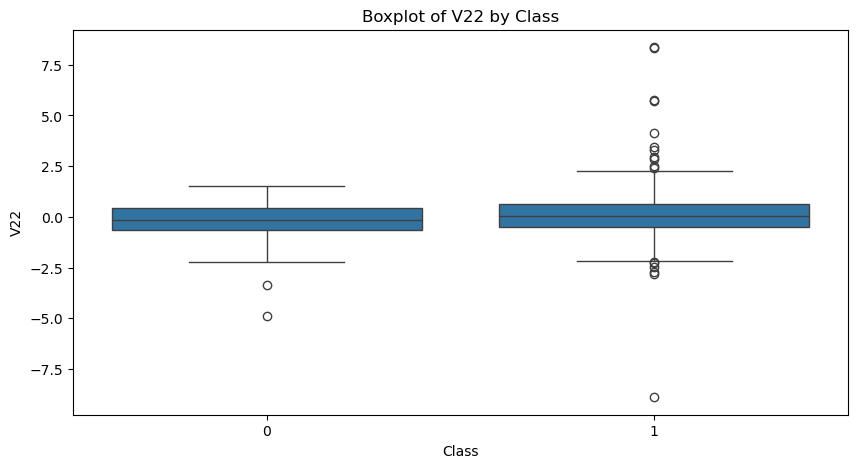

<Figure size 640x480 with 0 Axes>

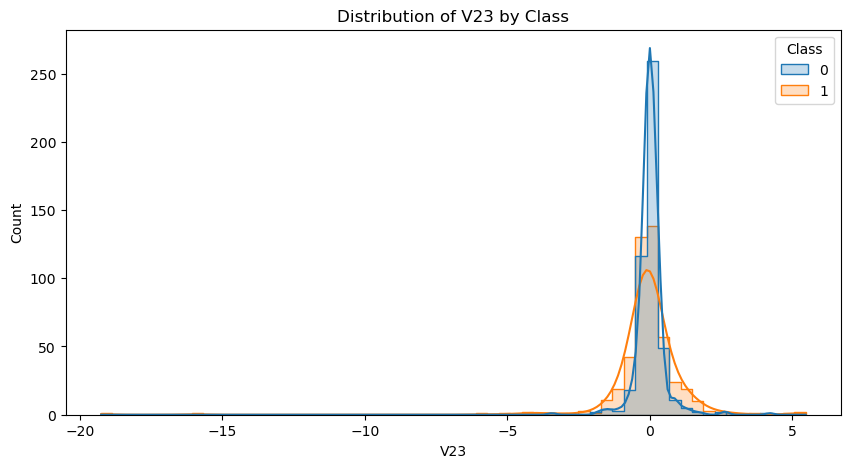

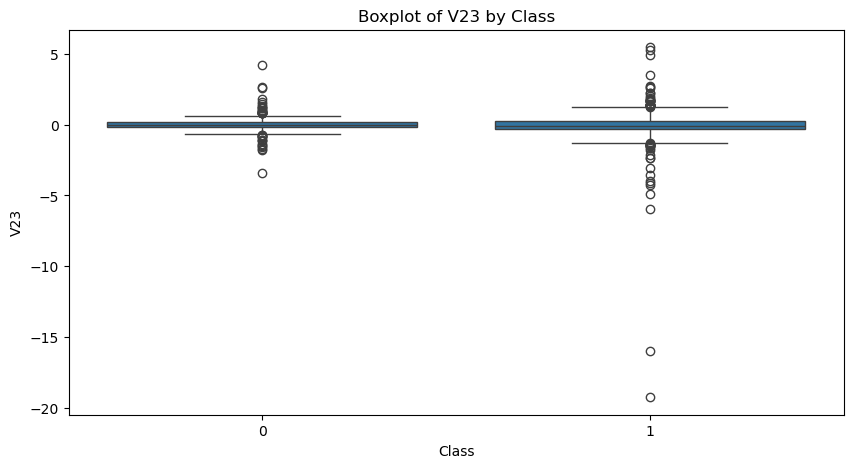

<Figure size 640x480 with 0 Axes>

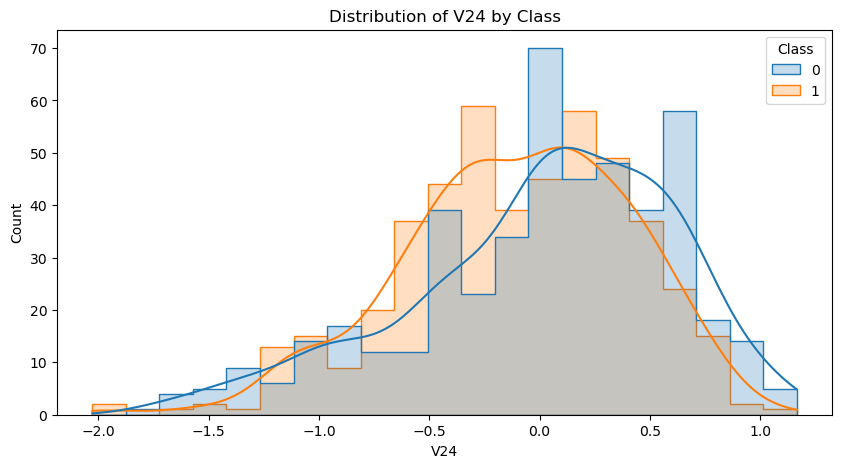

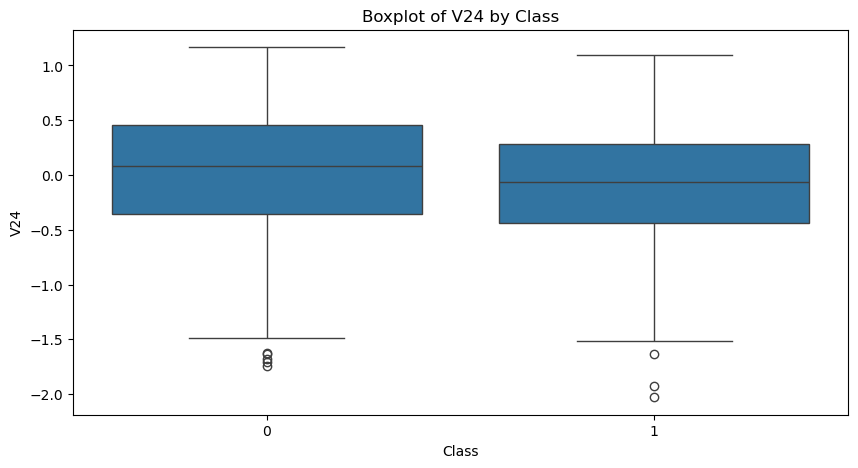

<Figure size 640x480 with 0 Axes>

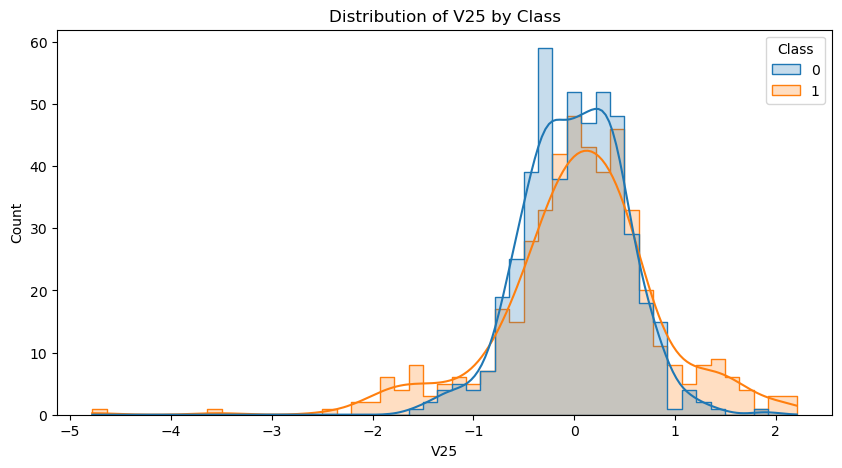

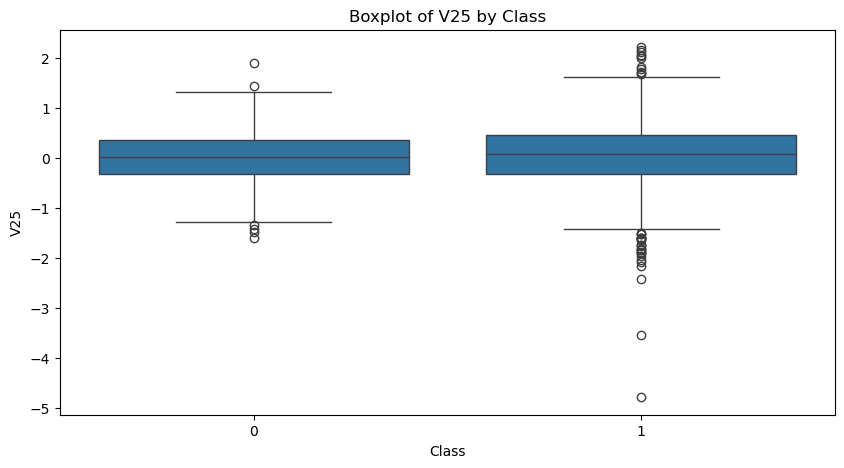

<Figure size 640x480 with 0 Axes>

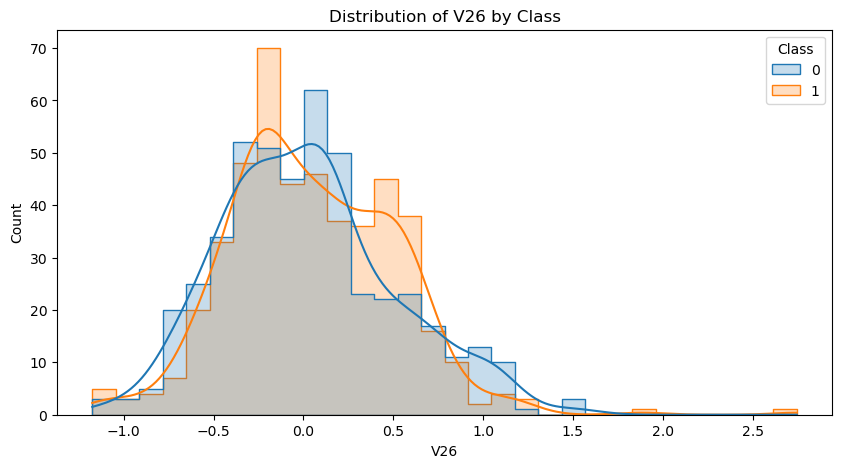

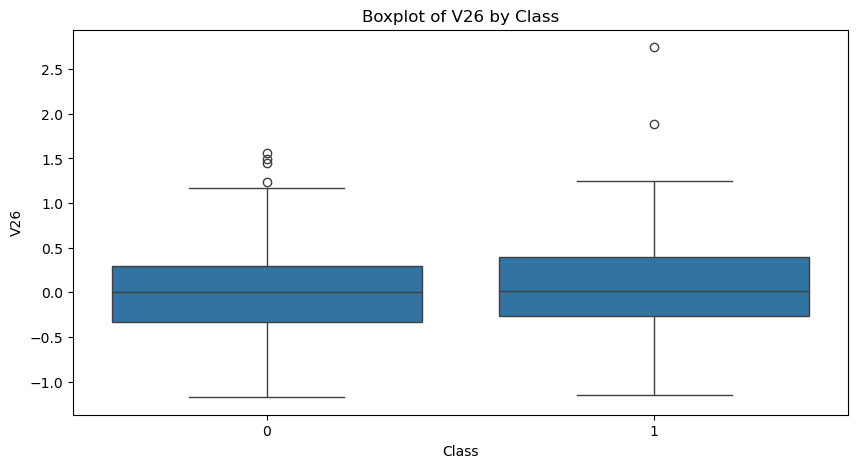

<Figure size 640x480 with 0 Axes>

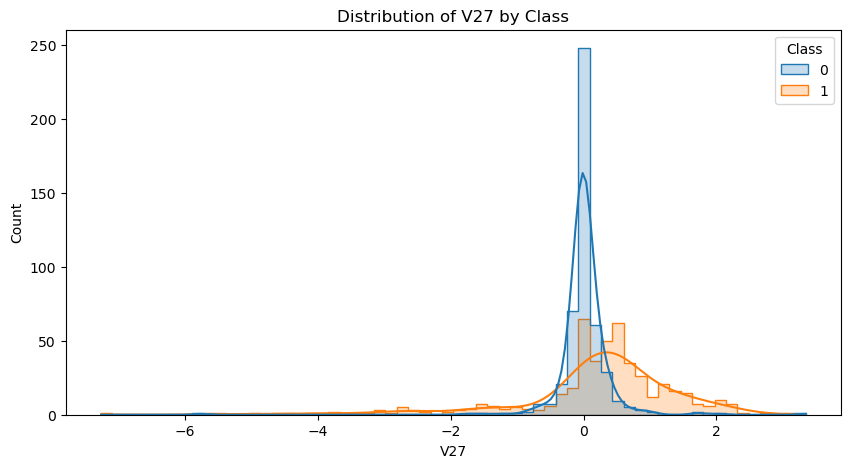

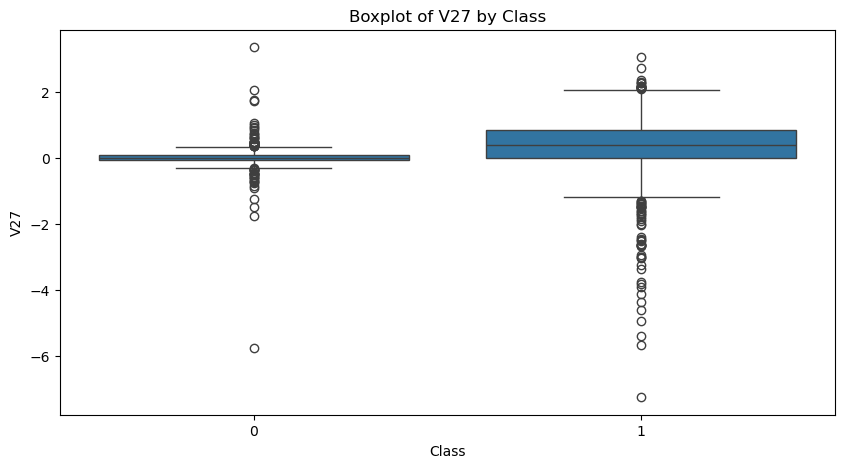

<Figure size 640x480 with 0 Axes>

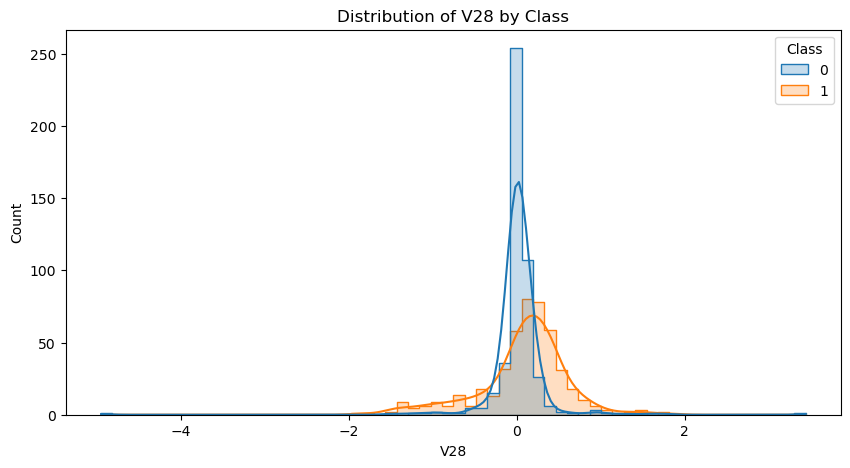

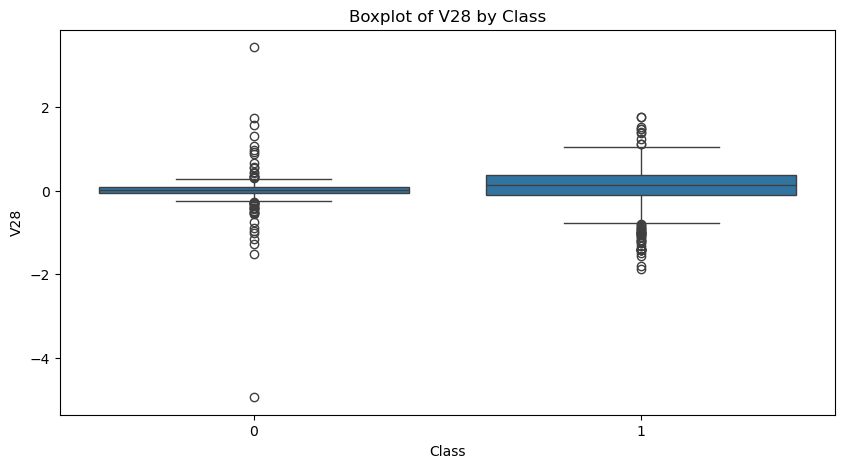

<Figure size 640x480 with 0 Axes>

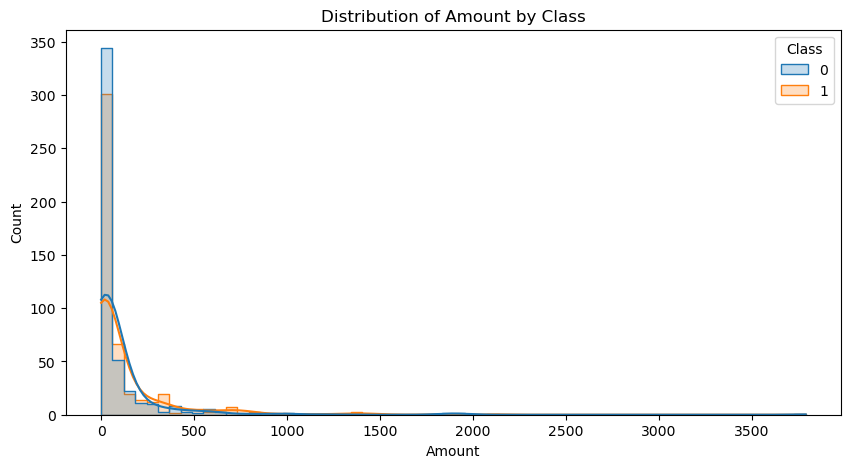

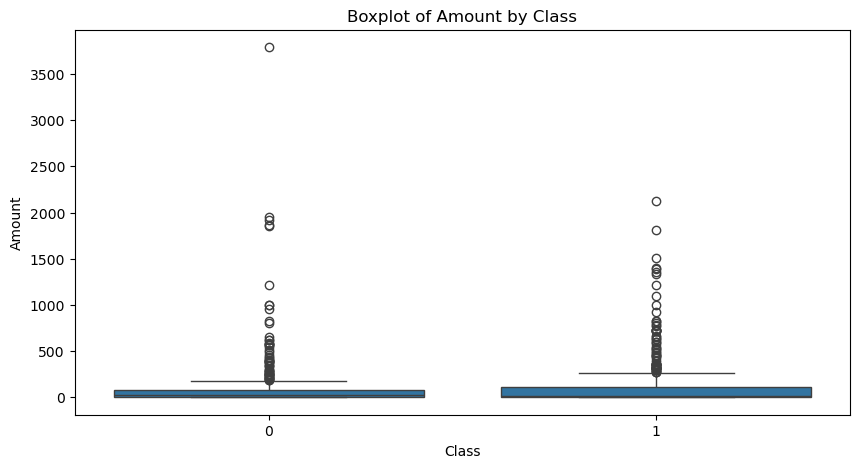

<Figure size 640x480 with 0 Axes>

In [31]:
for i in list(balanced_data.columns[:-1]):
    plt.figure(figsize=(10, 5))
    sns.histplot(data=balanced_data, x=i, hue="Class", kde=True, element="step")
    plt.title(f"Distribution of {i} by Class")
    plt.show()
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=balanced_data, x="Class", y=i)
    plt.title(f"Boxplot of {i} by Class")
    plt.show()
    plt.savefig(f"Visuals/{i}_distribution.png")

#### Train-Test Split the data first 